In [1]:
import requests
import csv
import pandas as pd
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import time
import random
from datetime import datetime, date
import statistics
import requests
from scipy.stats import skew, kurtosis
from scipy import stats
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import johnsonsu
from scipy.optimize import minimize
from scipy.stats import norm

In [2]:
def get_data(ticker, size='full', date_filter=None):
    """ Retrieve time series data for the price of a security in data frame format
        Sorts so that first date is first index, filters on date if given, renames columns and converts datatypes

    Args:
        ticker (string): The ticker for the security to pull data from
        size (string): 'full' since 1999, 'compact' is last 100 trading days
        date_filter (date string): Filters  data to  keep data only the filter date onward

    Returns:
        df: A dataframe with open, close, high, low, adj close price, volume, split coef, date
    """
    key='&apikey=ZKMMTO1ATDBLXH2K' # API Key
    api_ticker=f'&symbol={ticker}' # Ticker
    endpoint='function=TIME_SERIES_DAILY_ADJUSTED' # Called 'function', the dataset we want
    size=f'&outputsize={size}'
    web='https://www.alphavantage.co/query?'
    url =web+endpoint+api_ticker+size+key

    r = requests.get(url)
    # print(r.status_code) # 200 good, 400 bad
    data = r.json()

    # print(data.keys()) #printing the keys
    meta = data['Meta Data']
    time_series_data = data['Time Series (Daily)']

    ts_df = pd.DataFrame.from_dict(time_series_data, orient='index').reset_index().rename(columns={'index': 'Date'})
    clean_cols_dict = {'1. open': 'Open', '2. high': 'High', '3. low': 'Low', '4. close': 'Close', # Dictionary to convert the names of the columns
                '5. adjusted close': 'Adj Close', '6. volume': 'Volume', '7. dividend amount': 'Dividend', '8. split coefficient': 'Split Coef'}
    ts_df = ts_df.rename(columns=clean_cols_dict)

    ts_df['Date'] = pd.to_datetime(ts_df['Date'])
    if date_filter is not None:
        date_filter = pd.to_datetime(date_filter)
        ts_df = ts_df[ts_df['Date'] >= date_filter]


    ts_df = ts_df.sort_values(by='Date', ascending=True).reset_index().drop(columns='index')
    ts_df['Adj Close'] = ts_df['Adj Close'].astype('float').round(4)
    ts_df['Ticker'] = ticker
    
    return ts_df

In [3]:
def calculate_returns(df, frequency=1):
    """ Calculate the log returns of a security given a df with its prices over a time period

    Args:
        df (dataframe): A dataframe with columns Date, Ticker, Volume, and Adj Close
        frequency (int, optional): How often you want to calculate a return Defaults to 1.

    Returns:
        df: The dataframe from the start with an additional 'Log Return' column which is the log return over the interval for each row
    """
    returns_df = df[['Date', 'Ticker', 'Volume', 'Adj Close']].copy()
    returns_df['Adj Close'] = returns_df['Adj Close'].astype('float')
    returns_df['Log Return'] = np.log(
        returns_df['Adj Close'] / returns_df['Adj Close'].shift(frequency)
    )
    returns_df = returns_df.dropna()

    # If frequency > 1, keep only every `frequency`-th row
    if frequency > 1:
        returns_df = returns_df.iloc[frequency-1::frequency].reset_index(drop=True)

    return returns_df

In [5]:
# Daily log returns for XOM, CVX, VLO — 2-year lookback
tickers = ['XOM', 'CVX', 'VLO']
start = '2024-06-12'  # 2 years back from today (2026-06-12)

returns = {}
for t in tickers:
    prices = get_data(t, size='full', date_filter=start)
    returns[t] = calculate_returns(prices, frequency=1).rename(columns={'Adj Close': 'Price'})
    time.sleep(2)

returns['XOM']

,Date,Ticker,Volume,Price,Log Return
1,2024-06-13,XOM,14466868,103.0528,-0.008056
2,2024-06-14,XOM,13313430,102.1818,-0.008488
3,2024-06-17,XOM,21147943,101.4795,-0.006897
4,2024-06-18,XOM,17762915,102.4347,0.009369
5,2024-06-20,XOM,17433192,104.6449,0.021347
...,...,...,...,...,...
496,2026-06-05,XOM,16583961,149.9200,-0.014042
497,2026-06-08,XOM,13870875,151.7500,0.012133
498,2026-06-09,XOM,18163527,148.9100,-0.018892
499,2026-06-10,XOM,14596495,150.6200,0.011418


In [6]:
import statsmodels.api as sm

# Align all three series on common trading dates
df = pd.DataFrame({
    'XOM': returns['XOM'].set_index('Date')['Log Return'],
    'CVX': returns['CVX'].set_index('Date')['Log Return'],
    'VLO': returns['VLO'].set_index('Date')['Log Return'],
}).dropna()

X = sm.add_constant(df[['XOM', 'CVX']])  # add intercept column
y = df['VLO']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    VLO   R-squared:                       0.438
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     193.9
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           5.52e-63
Time:                        11:51:59   Log-Likelihood:                 1323.3
No. Observations:                 500   AIC:                            -2641.
Df Residuals:                     497   BIC:                            -2628.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.001      0.750      0.4

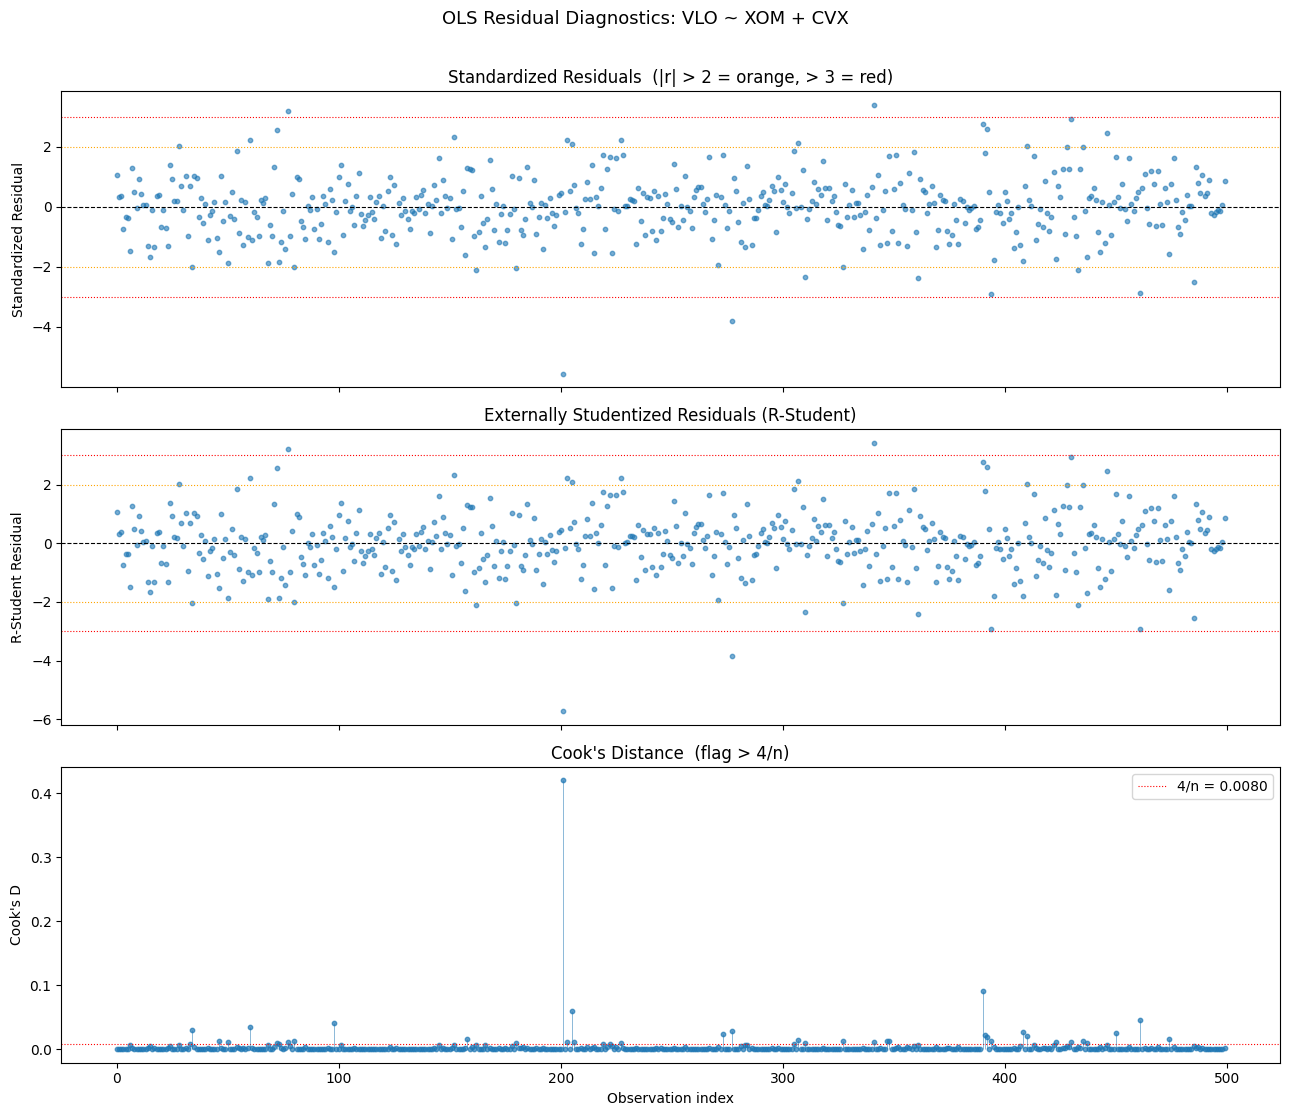

In [7]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(model)
dates = df.index
obs_idx = np.arange(len(df))

std_resid    = influence.resid_studentized_internal   # standardized residuals
rstudent     = influence.resid_studentized_external   # externally studentized (R-student)
cooksd       = influence.cooks_distance[0]            # Cook's D

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle('OLS Residual Diagnostics: VLO ~ XOM + CVX', fontsize=13, y=1.01)

# --- Panel 1: Standardized residuals ---
axes[0].axhline(0,  color='black', linewidth=0.8, linestyle='--')
axes[0].axhline( 2, color='orange', linewidth=0.8, linestyle=':')
axes[0].axhline(-2, color='orange', linewidth=0.8, linestyle=':')
axes[0].axhline( 3, color='red',    linewidth=0.8, linestyle=':')
axes[0].axhline(-3, color='red',    linewidth=0.8, linestyle=':')
axes[0].scatter(obs_idx, std_resid, s=10, alpha=0.6)
axes[0].set_ylabel('Standardized Residual')
axes[0].set_title('Standardized Residuals  (|r| > 2 = orange, > 3 = red)')

# --- Panel 2: Externally studentized residuals (R-student) ---
axes[1].axhline(0,  color='black', linewidth=0.8, linestyle='--')
axes[1].axhline( 2, color='orange', linewidth=0.8, linestyle=':')
axes[1].axhline(-2, color='orange', linewidth=0.8, linestyle=':')
axes[1].axhline( 3, color='red',    linewidth=0.8, linestyle=':')
axes[1].axhline(-3, color='red',    linewidth=0.8, linestyle=':')
axes[1].scatter(obs_idx, rstudent, s=10, alpha=0.6)
axes[1].set_ylabel('R-Student Residual')
axes[1].set_title('Externally Studentized Residuals (R-Student)')

# --- Panel 3: Cook's Distance ---
threshold = 4 / len(df)   # common rule of thumb: flag if Cook's D > 4/n
axes[2].axhline(threshold, color='red', linewidth=0.8, linestyle=':', label=f'4/n = {threshold:.4f}')
axes[2].vlines(obs_idx, 0, cooksd, linewidth=0.6, alpha=0.6)
axes[2].scatter(obs_idx, cooksd, s=10, alpha=0.7)
axes[2].set_ylabel("Cook's D")
axes[2].set_title("Cook's Distance  (flag > 4/n)")
axes[2].legend()
axes[2].set_xlabel('Observation index')

plt.tight_layout()
plt.show()